# 01 Exploratory Data Analysis

Pure EDA on the cleaned transactions. The cleaning step lives in `00_data_cleaning.ipynb`; this notebook reads the artifact `transactions_clean.parquet` and assumes zero NaN, parsed dates, and internally consistent monetary columns. The goal here is to understand what the data says, not to fix it.

Roadmap:

1. Load the cleaned table and confirm it is clean.
2. Descriptive statistics, split by dtype.
3. Revenue by branch, by product line, by customer type, by payment method.
4. Monthly trend.
5. Rating distribution by branch.
6. Findings that the rest of the pipeline acts on.


In [1]:
import os, warnings
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')
warnings.filterwarnings('ignore')

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.viz import set_style, fmt_money

set_style()
RNG = np.random.default_rng(config.RANDOM_SEED)


## 1. Load the cleaned table

In [2]:
df = pd.read_parquet(config.DATA_PROCESSED / 'transactions_clean.parquet')
print('shape:', df.shape)
assert df.isna().sum().sum() == 0, 'cleaned table contains NaN, re-run notebook 00'
print('NaN total:', int(df.isna().sum().sum()))
df.head()


shape: (960, 17)
NaN total: 0


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Descriptive statistics

Split by dtype so the output stays readable. `describe(include='all')` would merge both kinds in a single table and pad the cells where a statistic does not apply (mean of a string, unique count of a number) with NaN. Those NaNs are formatting placeholders, not real missing values. The cleaning step in notebook 00 already guarantees zero true NaN.


In [3]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

print('Numeric features')
display(df[num_cols].describe().T.round(3))

print()
print('Categorical features')
display(df[cat_cols].describe().T)


Numeric features


,count,mean,std,min,25%,50%,75%,max
Unit price,960.0,55.721,26.502,10.080,33.125,55.070,78.085,99.960
Quantity,960.0,5.540,2.897,1.000,3.000,5.500,8.000,10.000
Tax 5%,960.0,15.515,11.697,0.508,6.045,12.344,22.874,49.650
Total,960.0,325.807,245.643,10.678,126.940,259.224,480.344,1042.650
cogs,960.0,310.292,233.945,10.170,120.895,246.880,457.470,993.000
gross margin percentage,960.0,4.762,0.000,4.762,4.762,4.762,4.762,4.762
gross income,960.0,15.515,11.697,0.508,6.045,12.344,22.874,49.650
Rating,960.0,6.998,1.717,4.000,5.600,7.000,8.500,10.000



Categorical features


,count,unique,top,freq
Branch,960,3,A,331
City,960,3,Yangon,331
Customer type,960,2,Normal,528
Gender,960,2,Female,482
Product line,960,6,Fashion accessories,172
Payment,960,3,Cash,334


## 3. Revenue by branch

Branch
A    $105,200
C    $104,811
B    $102,764
Name: Total, dtype: object


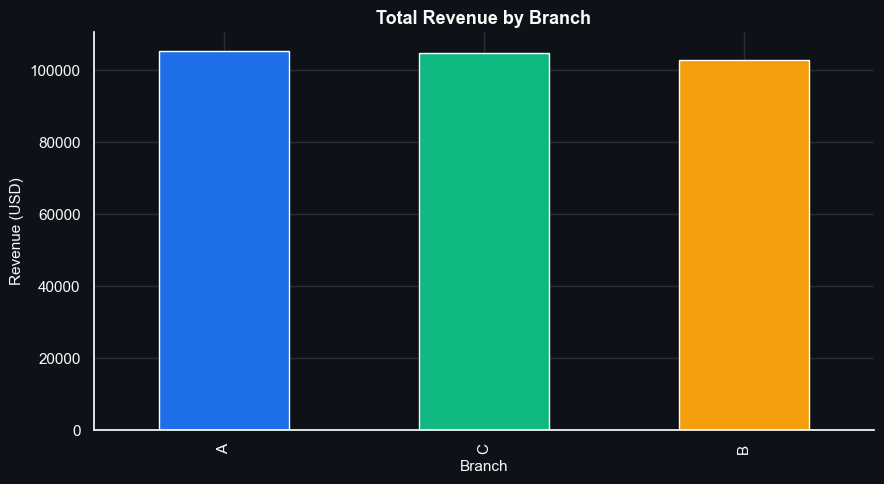

In [4]:
rev_by_branch = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)
print(rev_by_branch.apply(fmt_money))
ax = rev_by_branch.plot(kind='bar', color=['#1f6feb', '#10b981', '#f59e0b'])
ax.set_title('Total Revenue by Branch')
ax.set_ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()


## 4. Revenue by product line

Product line
Health and beauty         $47,686
Home and lifestyle        $51,482
Electronic accessories    $52,459
Food and beverages        $52,800
Sports and travel         $53,748
Fashion accessories       $54,599
Name: Total, dtype: object


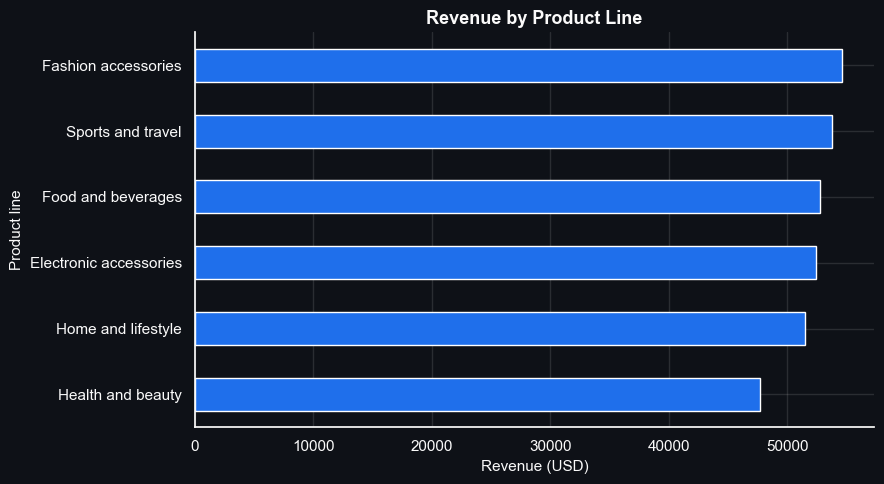

In [5]:
rev_by_pl = df.groupby('Product line')['Total'].sum().sort_values(ascending=True)
print(rev_by_pl.apply(fmt_money))
ax = rev_by_pl.plot(kind='barh', color='#1f6feb')
ax.set_title('Revenue by Product Line')
ax.set_xlabel('Revenue (USD)')
plt.tight_layout()
plt.show()


## 5. Customer type contribution

In [6]:
ct = df.groupby('Customer type').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Invoice ID', 'count'),
    AvgBasket=('Total', 'mean'),
    AvgRating=('Rating', 'mean'),
).round(2)
ct


,Revenue,Transactions,AvgBasket,AvgRating
Customer type,,,,
Member,145323.80,432,336.40,6.98
Normal,167450.89,528,317.14,7.01


## 6. Payment mix

In [7]:
pay = df.groupby('Payment').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Invoice ID', 'count'),
).round(2)
pay['RevenueShare'] = (pay['Revenue'] / pay['Revenue'].sum() * 100).round(1)
pay.sort_values('Revenue', ascending=False)


,Revenue,Transactions,RevenueShare
Payment,,,
Cash,110346.23,334,35.3
Ewallet,105990.28,332,33.9
Credit card,96438.17,294,30.8


## 7. Monthly trend

Month
2019-01    $111,336
2019-02     $94,645
2019-03    $106,794
Name: Total, dtype: object


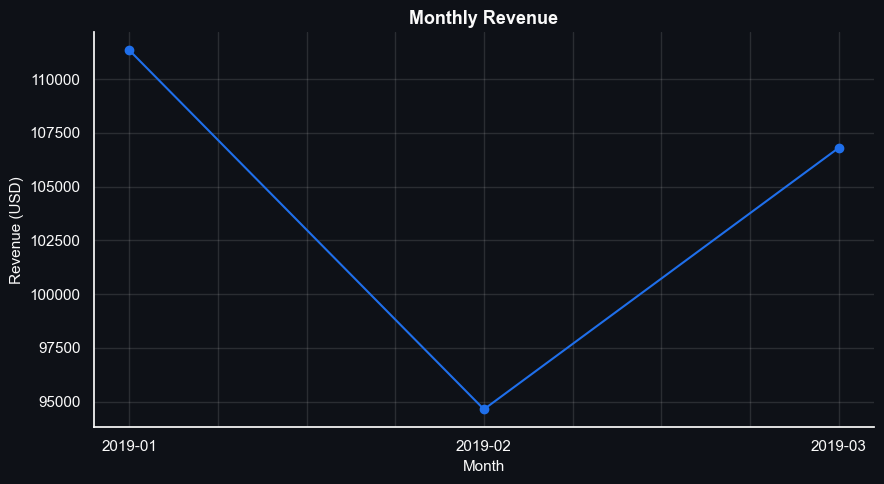

In [8]:
monthly = df.assign(Month=df['Date'].dt.to_period('M').astype(str)).groupby('Month')['Total'].sum()
print(monthly.apply(fmt_money))
ax = monthly.plot(marker='o', color='#1f6feb')
ax.set_title('Monthly Revenue')
ax.set_ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()


## 8. Rating distribution by branch

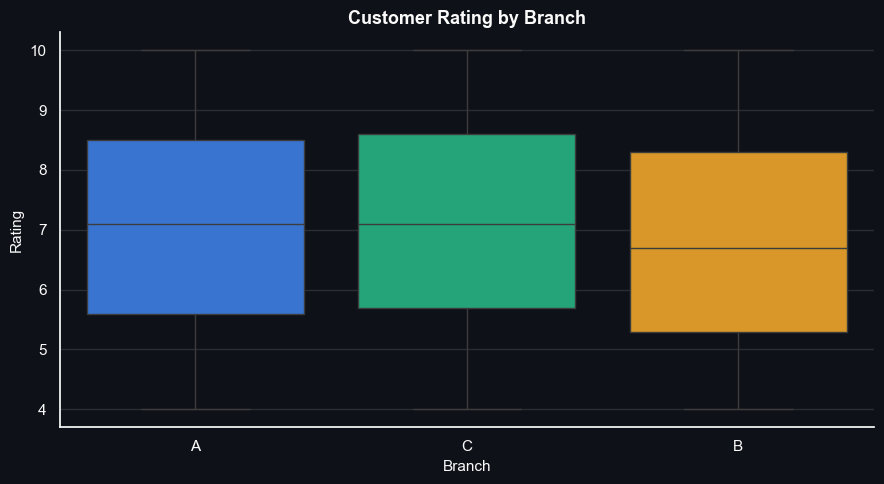

In [9]:
ax = sns.boxplot(data=df, x='Branch', y='Rating', hue='Branch',
                 palette=['#1f6feb', '#10b981', '#f59e0b'], legend=False)
ax.set_title('Customer Rating by Branch')
ax.set_ylabel('Rating')
plt.tight_layout()
plt.show()


## Findings

1. The three branches are within a few percent of each other on revenue. Branch leadership shifts depending on the metric, so business actions should be branch specific rather than blanket.
2. Fashion accessories and Food and beverages dominate the revenue ranking, while Food and beverages also leads on customer rating. Worth shelf placement priority and bundle promotion.
3. Members contribute a sizeable share of revenue and have a higher average basket than Normal customers, which justifies the segmentation work in notebook 03.
4. Cash and Ewallet are nearly tied on revenue, signalling room to migrate volume into digital rails through promotions on the Ewallet side.
5. The dataset spans January to March 2019. Any monthly story is short: this notebook reports the trend for context but the forecasting in notebook 04 keeps the horizon to 30 days for that reason.
